In [1]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dense(38, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1780665309.874710    2094 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780665309.937578    2094 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780665311.644743    2094 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1780665313.467397    2094 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [2]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [3]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop]
)

NameError: name 'train_generator' is not defined

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "crop_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "crop_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [5]:
print(train_generator.samples)
print(valid_generator.samples)

70295
17572


In [6]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20


I0000 00:00:1780665445.806777    2094 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1859s 844ms/step - accuracy: 0.8405 - loss: 0.5097 - val_accuracy: 0.9057 - val_loss: 0.2824
Epoch 2/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1842s 838ms/step - accuracy: 0.8945 - loss: 0.3139 - val_accuracy: 0.9238 - val_loss: 0.2279
Epoch 3/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1854s 844ms/step - accuracy: 0.9059 - loss: 0.2757 - val_accuracy: 0.9181 - val_loss: 0.2411
Epoch 4/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1836s 836ms/step - accuracy: 0.9148 - loss: 0.2526 - val_accuracy: 0.9257 - val_loss: 0.2146
Epoch 5/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1841s 838ms/step - accuracy: 0.9187 - loss: 0.2429 - val_accuracy: 0.9408 - val_loss: 0.1738
Epoch 6/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1863s 848ms/step - accuracy: 0.9227 - loss: 0.2280 - val_accuracy: 0.9411 - val_loss: 0.1732
Epoch 7/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1919s 873ms/step - accuracy: 0.9273 - loss: 0.2185 - val_accuracy: 0.9417 - val_loss: 0.1704
Epoch 8/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1906s 867ms/step - accur

In [9]:
model.save("/home/ubuntu/crop_disease_model.keras")

In [10]:
import os
print(os.path.exists("/home/ubuntu/crop_disease_model.keras"))

True


In [11]:
class_names = list(train_generator.class_indices.keys())

print(class_names)
print(len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [12]:
import json

class_names = list(train_generator.class_indices.keys())

with open("/home/ubuntu/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved successfully")

Saved successfully


In [13]:
import os

print(os.path.exists("/home/ubuntu/class_names.json"))

True


In [14]:
from tensorflow.keras.models import load_model

model = load_model("/home/ubuntu/crop_disease_model.keras")

print("Model loaded successfully")

Model loaded successfully


In [15]:
import json
import numpy as np
from tensorflow.keras.preprocessing import image

# Load class names
with open("/home/ubuntu/class_names.json", "r") as f:
    class_names = json.load(f)

# Load image
img_path = "test_leaf.jpg"   # change this
img = image.load_img(img_path, target_size=(224, 224))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

FileNotFoundError: [Errno 2] No such file or directory: 'test_leaf.jpg'

In [16]:
import os

print(os.getcwd())
print(os.listdir())

/home/ubuntu
['.bashrc', '.ipynb_checkpoints', '.local', 'crop_disease_model.h5', '.profile', 'crop-frontend', '.sudo_as_admin_successful', 'BUILD_FROM_SOURCE_PACKAGES_LICENCES', '.config', '.jupyter', 'OSSNvidiaDriver_v580.126.16_license.txt', 'crop_dataset', 'archive.zip', '.npm', 'mobilenetv2_plantdoc.h5', '.ssh', 'mobilenetv2_plantdoc.keras', 'model.ipynb', 'class_names.json', '.cache', 'crop_disease_model.keras', '.gnupg', 'PlantDoc-Dataset', 'Untitled.ipynb', 'LINUX_PACKAGES_LIST', '.ipython', 'my-react-app', 'LINUX_PACKAGES_LICENSES', 'PlantDoc-Dataset-model.h5', '.wget-hsts', 'PlantDoc-Dataset-model.keras', '.bash_logout', 'THIRD_PARTY_SOURCE_CODE_URLS', '.keras', 'PYTHON_PACKAGES_LICENSES', '.bash_history', '.viminfo']


In [18]:
import os

for file in os.listdir():
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        print(file)

In [19]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current folder:
/home/ubuntu

Files:
['.bashrc', '.ipynb_checkpoints', '.local', 'crop_disease_model.h5', '.profile', 'crop-frontend', '.sudo_as_admin_successful', 'BUILD_FROM_SOURCE_PACKAGES_LICENCES', '.config', '.jupyter', 'OSSNvidiaDriver_v580.126.16_license.txt', 'crop_dataset', 'archive.zip', '.npm', 'mobilenetv2_plantdoc.h5', '.ssh', 'mobilenetv2_plantdoc.keras', 'model.ipynb', 'class_names.json', '.cache', 'crop_disease_model.keras', '.gnupg', 'PlantDoc-Dataset', 'Untitled.ipynb', 'LINUX_PACKAGES_LIST', '.ipython', 'my-react-app', 'LINUX_PACKAGES_LICENSES', 'PlantDoc-Dataset-model.h5', '.wget-hsts', 'PlantDoc-Dataset-model.keras', '.bash_logout', 'THIRD_PARTY_SOURCE_CODE_URLS', '.keras', 'PYTHON_PACKAGES_LICENSES', '.bash_history', '.viminfo']


In [20]:
import os

for file in os.listdir():
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        print(file)

Apple Leaf Counts.jpg


In [21]:
img_path = "test_leaf.jpg"

In [22]:
img_path = "Apple Leaf Counts.jpg"

In [23]:
# Load image
img_path = "Apple Leaf Counts.jpg"
img = image.load_img(img_path, target_size=(224, 224))

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x75322bcee480>

In [24]:
import os

print(os.path.getsize("Apple Leaf Counts.jpg"))

98642


In [25]:
from PIL import Image

Image.open("Apple Leaf Counts.jpg")

UnidentifiedImageError: cannot identify image file 'Apple Leaf Counts.jpg'

In [26]:
import os

sample_class = os.listdir(train_dir)[0]
sample_folder = os.path.join(train_dir, sample_class)

sample_image = os.path.join(sample_folder, os.listdir(sample_folder)[0])

print("Class:", sample_class)
print("Image:", sample_image)

Class: Strawberry___Leaf_scorch
Image: crop_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Strawberry___Leaf_scorch/f265851b-622d-44a1-b09e-95bfe6aea62f___RS_L.Scorch 0998.JPG


In [27]:
img_path = sample_image
print(img_path)

crop_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Strawberry___Leaf_scorch/f265851b-622d-44a1-b09e-95bfe6aea62f___RS_L.Scorch 0998.JPG


In [28]:
import json
import numpy as np
from tensorflow.keras.preprocessing import image

with open("/home/ubuntu/class_names.json", "r") as f:
    class_names = json.load(f)

img = image.load_img(img_path, target_size=(224, 224))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Disease: Strawberry___Leaf_scorch
Confidence: 99.98 %


In [29]:
model.save("crop_disease_model.h5")

print("Model Saved!")

Model Saved!


In [30]:
from tensorflow.keras.preprocessing import image

img_path = "/content/test_leaf.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

print("Disease:", predicted_class)
print("Confidence:", round(confidence,2), "%")

FileNotFoundError: [Errno 2] No such file or directory: '/content/test_leaf.jpg'

In [31]:
plt.imshow(img)
plt.axis("off")

plt.title(
    f"{predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()

NameError: name 'plt' is not defined

In [32]:
import matplotlib.pyplot as plt

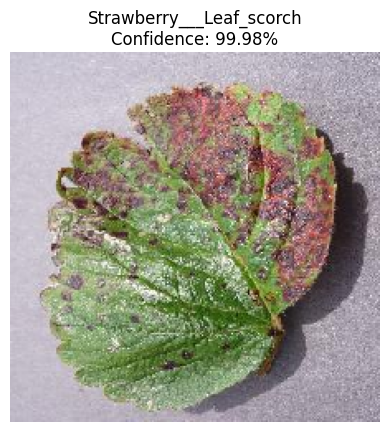

In [33]:
plt.imshow(img)
plt.axis("off")

plt.title(
    f"{predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()